In [1]:
from cellsweep.simulation import simulate_cells
from cellsweep.simulation import simple_simulation
import cellsweep.utils as cs_utils
from cellsweep import denoise_count_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os

cellsweep_dir = os.path.dirname(os.path.abspath(""))
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "debug_sim")

In [2]:
%matplotlib widget

In [3]:
data = simulate_cells(G=10000, N=8000, empty_prob=0.8)

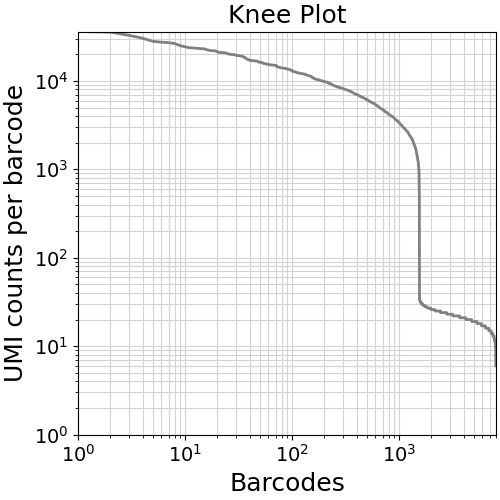

In [4]:
cs_utils.knee_plot(data)

In [5]:
adata_cellmender_path = os.path.join(out_dir, "adata_cellmender.h5ad")
adata_log_path = os.path.join(out_dir, "cellmender.log")


denoised_data = denoise_count_matrix(data, verbose=2, threads=8, adata_out = adata_cellmender_path, log_file = adata_log_path)

17:36:20 - INFO - Inferring celltype profiles.
17:36:20 - DEBUG - Number of parameters in the cellmender model: 50,001 alpha: 1,543, beta: 1, p_k: 50,000)
17:36:21 - INFO - Inferring the gene ambient profile from empty droplets.
17:36:21 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
17:36:21 - INFO - Performing Sparse EM with 8 Numba thread(s)


Logging to /Users/mcaskey/Desktop/cellsweep/notebooks/output/debug_sim/cellmender.log


17:36:22 - INFO - EM Iter   1: ll=-79947598.879 min_alpha=0.7537 mean_alpha=0.8472 median_alpha=0.8495 max_alpha=0.8645 beta=0.104047
17:36:22 - INFO - EM Iter   2: ll=-79329315.192 min_alpha=0.6125 mean_alpha=0.7654 median_alpha=0.7692 max_alpha=0.8184 beta=0.101084
17:36:22 - INFO - EM Iter   3: ll=-78922397.146 min_alpha=0.5180 mean_alpha=0.6939 median_alpha=0.6979 max_alpha=0.7806 beta=0.096081
17:36:22 - INFO - EM Iter   4: ll=-78710724.956 min_alpha=0.4463 mean_alpha=0.6376 median_alpha=0.6415 max_alpha=0.7462 beta=0.090915
17:36:22 - INFO - EM Iter   5: ll=-78578824.946 min_alpha=0.3758 mean_alpha=0.5921 median_alpha=0.5958 max_alpha=0.7126 beta=0.085923
17:36:22 - INFO - EM Iter   6: ll=-78487566.065 min_alpha=0.3208 mean_alpha=0.5544 median_alpha=0.5584 max_alpha=0.6801 beta=0.081235
17:36:22 - INFO - EM Iter   7: ll=-78420168.151 min_alpha=0.2773 mean_alpha=0.5226 median_alpha=0.5271 max_alpha=0.6495 beta=0.076882
17:36:22 - INFO - EM Iter   8: ll=-78367977.556 min_alpha=0.24

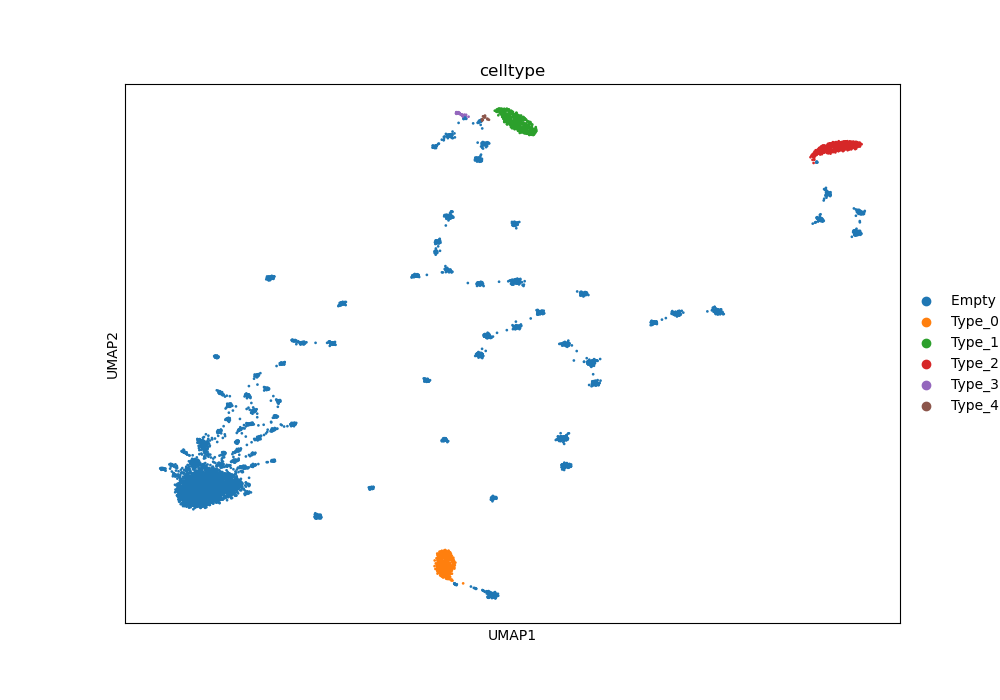

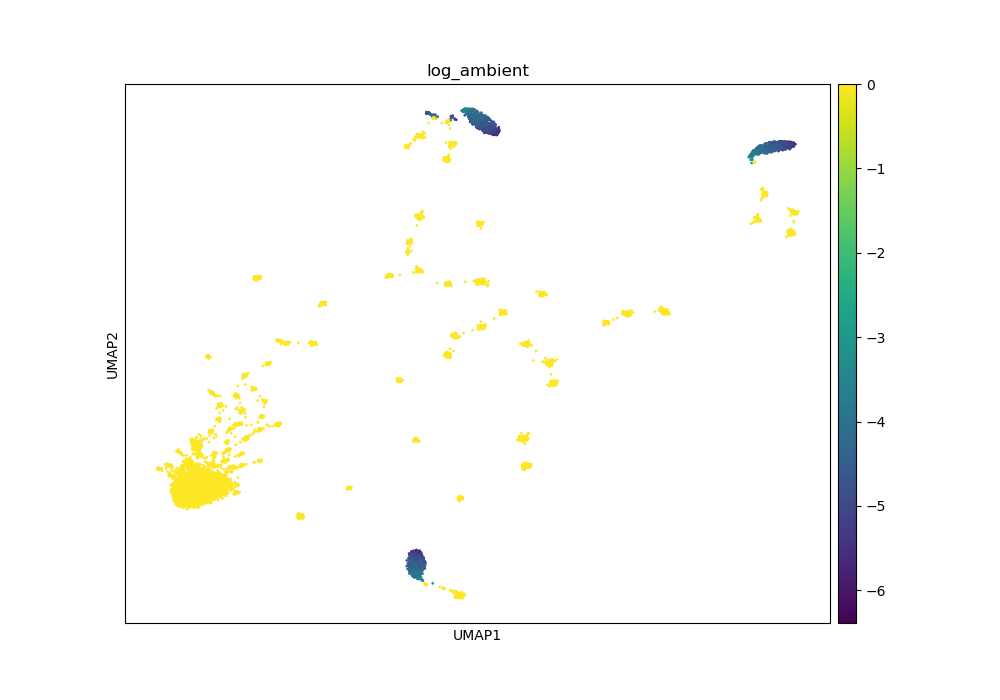

In [6]:
sc.pp.pca(data, n_comps=30)
sc.pp.neighbors(data, n_neighbors=30, n_pcs=30, knn=True)
sc.tl.umap(data)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='celltype', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
data.obs['log_ambient'] = np.log(data.obs['ambient_fraction'])
sc.pl.umap(data, color='log_ambient', ax=ax)

In [7]:
real_mask = ~denoised_data.obs["is_empty"]
print(denoised_data.obs[real_mask])

           cellid celltype  is_empty  ambient_fraction      lib_size  \
Cell_2          1   Type_0     False          0.008826  10769.844446   
Cell_13         2   Type_1     False          0.013309   7020.196873   
Cell_36         3   Type_2     False          0.021265   5301.430253   
Cell_41         2   Type_1     False          0.009647   9654.391176   
Cell_47         2   Type_1     False          0.009074   8863.274881   
...           ...      ...       ...               ...           ...   
Cell_7970       2   Type_1     False          0.008577   8621.253264   
Cell_7973       3   Type_2     False          0.006243  12430.731439   
Cell_7981       2   Type_1     False          0.012129   6292.578014   
Cell_7982       4   Type_3     False          0.010759   8412.954624   
Cell_7995       2   Type_1     False          0.005744  13260.444688   

           cell_ambient_fraction  alpha_hat  z_hat  
Cell_2                       0.9   0.045889      1  
Cell_13                      

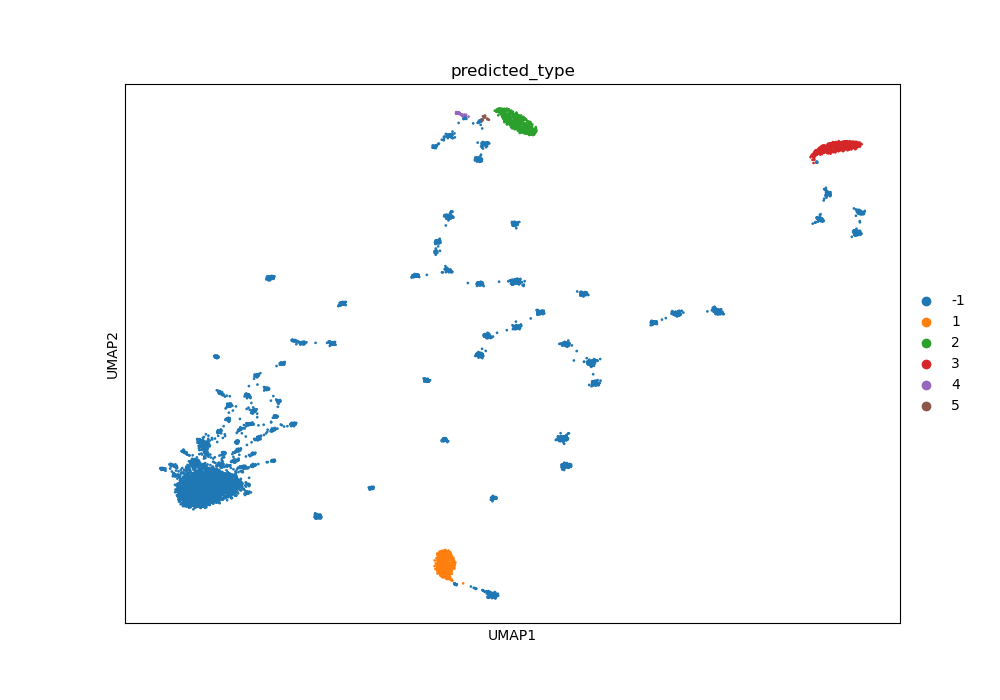

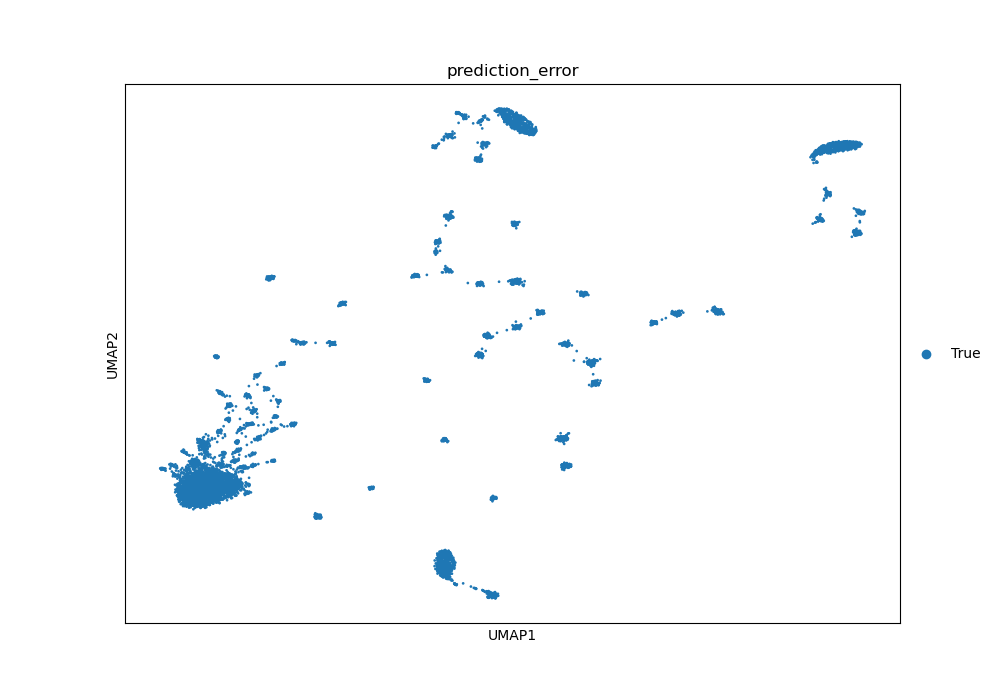

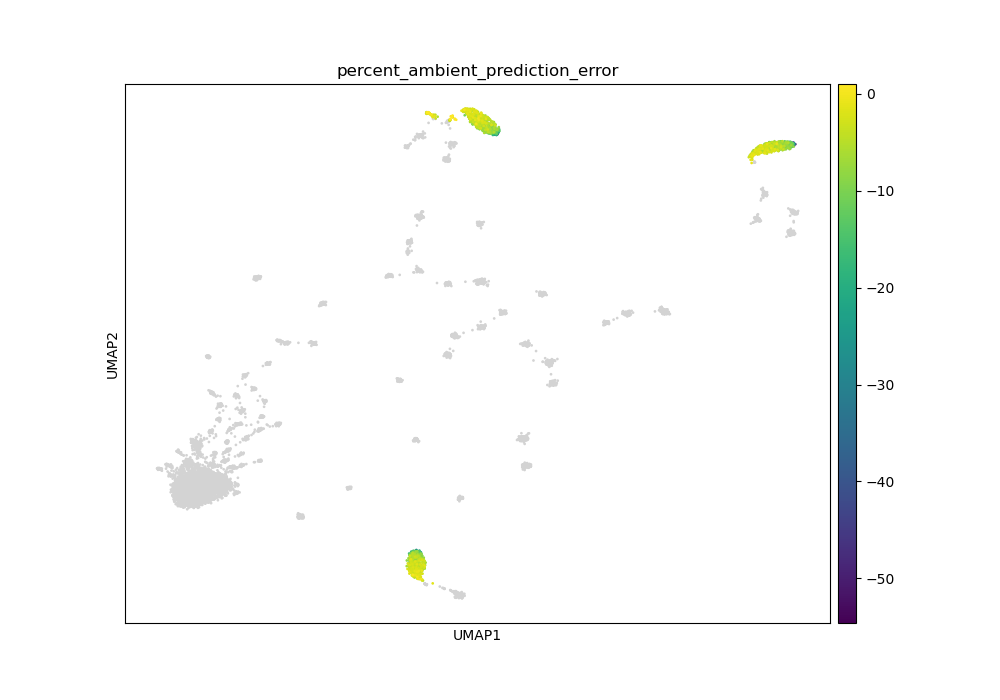

In [8]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'].astype(int) == denoised_data.obs['cellid'].astype(int))

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)

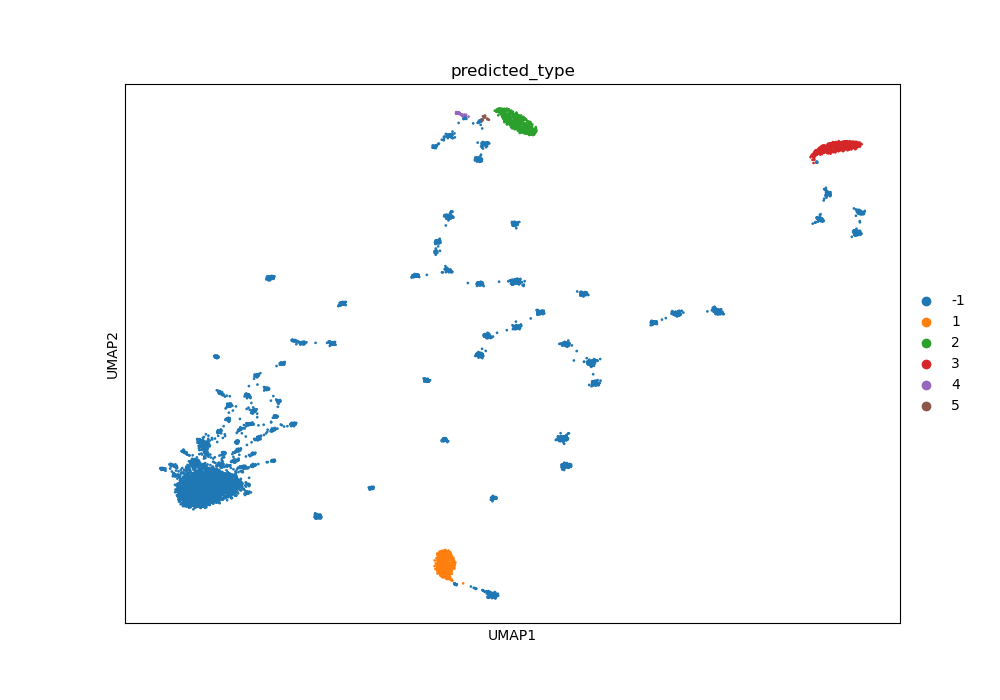

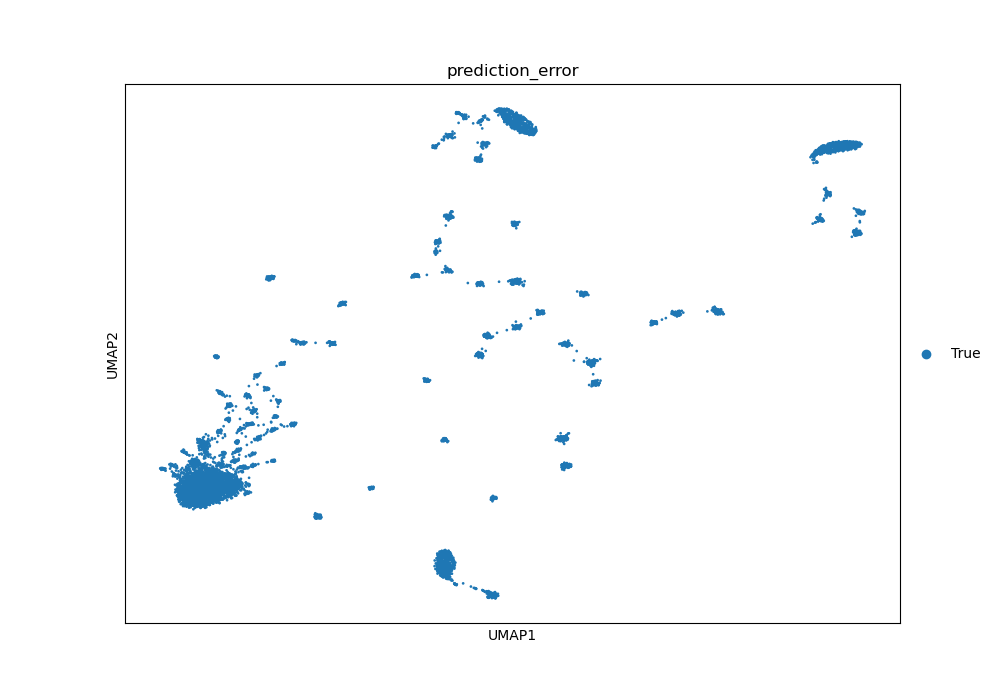

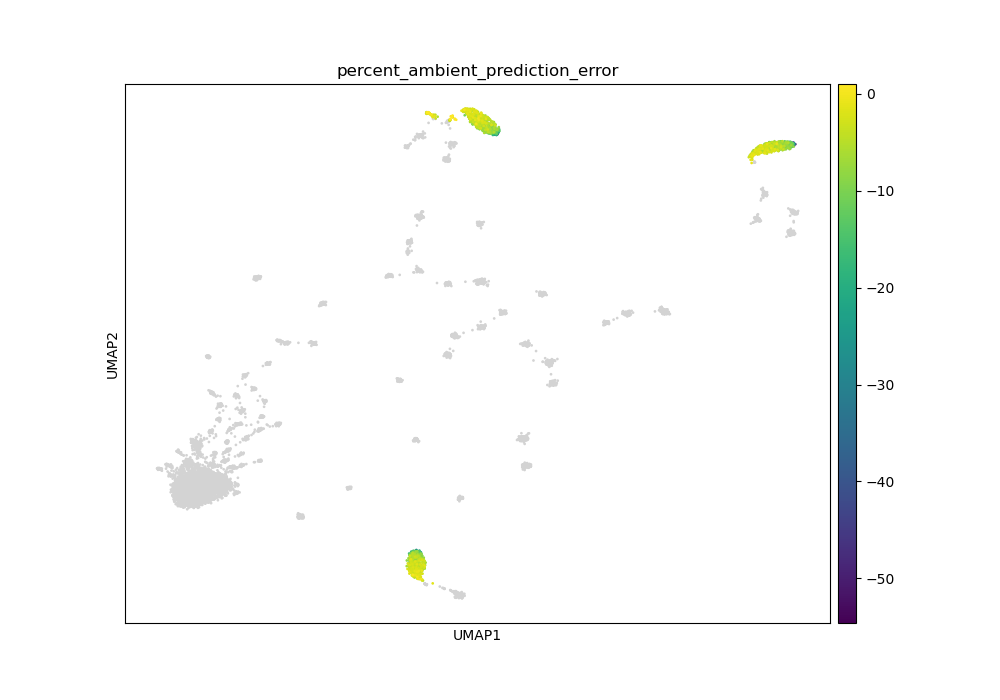

In [9]:
data.obs['percent_ambient_prediction_error'] = (data.obs['ambient_fraction'] - denoised_data.obs['alpha_hat'])/data.obs['ambient_fraction']
data.obs['percent_ambient_prediction_error'] = data.obs['percent_ambient_prediction_error'].mask(~real_mask, np.nan)
data.obs['predicted_type'] = denoised_data.obs['z_hat'].astype('category')
data.obs['prediction_error'] = (denoised_data.obs['z_hat'] == denoised_data.obs['cellid'])

fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='predicted_type', ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='prediction_error',ax=ax)
fig, ax = plt.subplots(figsize=(10, 7))
sc.pl.umap(data, color='percent_ambient_prediction_error', ax=ax)